# Лабораторна робота № 2

## Оптимізаційна задача та аналіз чутливості

**Дисципліна:** Інтелектуальний аналіз та візуалізація даних (СК26)
**Тривалість:** 2 год аудиторно + 3 год самостійної роботи · **Максимальна оцінка:** 4 бали

---

### Мета роботи

Побудувати оптимізаційну модель у двох середовищах, прочитати звіт про стійкість
і **ухвалити на його основі господарське рішення**.

Розв'язати задачу — не мета. Solver зробить це за дві секунди. Робота оцінюється за
те, що ви зумієте зі звіту витягнути.

### Дві частини

| Частина | Задача | Де виконується |
|---|---|---|
| **1** | виробнича задача — Excel і Python | аудиторно |
| **2** | транспортна задача — Python | самостійно |

Друга частина потрібна не для повторення. Там та сама методика поводиться інакше,
і ви маєте побачити, де саме проходить межа її застосовності.

### Що здається

1. Цей файл `.ipynb` із заповненими розв'язками. **Виконується згори донизу на чистому
   ядрі** (Kernel → Restart & Run All) без помилок — перевіряється першою дією на захисті.
2. Файл Excel з моделлю, налаштуваннями Solver і **звітом про стійкість** окремим аркушем.
3. Заповнена декларація про використання ШІ (етап 12).

### Оцінювання

| Бали | Що досягнуто |
|---|---|
| 0 | Модель не сформульовано або розв'язок не отримано |
| 1 | Розв'язок отримано лише в одному середовищі, звіт про стійкість не проаналізовано |
| 2 | Задачу розв'язано в обох середовищах і звіти зіставлено, але тіньові ціни та діапазони не інтерпретовано |
| 4 | Звіт прочитано й перевірено експериментом, ухвалено обґрунтоване рішення про закупівлю, виконано частину 2 з поясненням розбіжності |

---
## Крок 0. Ваші дані та варіант

In [42]:
ПІБ = 'Гуменюк Анастасія'        # напр. 'Шевченко Тарас'
ГРУПА = 'ШІ-31'      # напр. 'КН-31'
ВАРІАНТ = 5     # ваш номер за списком групи

assert ПІБ and ГРУПА and 1 <= ВАРІАНТ <= 30, 'Заповніть ПІБ, ГРУПУ та ВАРІАНТ (1..30)'

In [43]:
# --- клітинку не редагувати: вона видає дані вашого варіанта -----------------
import json, numpy as np, pandas as pd

ДАНІ_ВАРІАНТІВ = json.loads('''{"1": {"фірма": "«Астро-ТВ»", "що": "телевізори", "од": "шт./день", "вироби": ["Astro", "Cosmo", "Nova", "Vega"], "ресурси": ["Конвеєр A, год", "Конвеєр Б, год", "Цех кінескопів, год", "Цех корпусів, год", "Ділянка збирання, год"], "A": [[0, 2, 1, 1], [3, 3, 0, 6], [2, 3, 0, 2], [4, 6, 0, 5], [3, 1, 5, 4]], "c": [21, 69, 44, 39], "b": [929, 410, 507, 865, 425], "ресурс_пропозиції": 1, "ціна_пропозиції": 16.2, "обсяг_пропозиції": 44}, "2": {"фірма": "«Longer Boats»", "що": "яхти", "од": "шт./місяць", "вироби": ["Sting", "Ray", "Breaker", "Marlin"], "ресурси": ["Склопластик, м²", "Столярний цех, год", "Фарбувальний цех, год", "Такелаж, компл.", "Ділянка добудови, год"], "A": [[4, 2, 5, 2], [6, 5, 4, 2], [5, 2, 0, 3], [2, 1, 5, 0], [5, 5, 6, 2]], "c": [40, 66, 24, 34], "b": [1271, 702, 915, 1388, 804], "ресурс_пропозиції": 1, "ціна_пропозиції": 16.7, "обсяг_пропозиції": 204}, "3": {"фірма": "«Карпатський дуб»", "що": "меблі", "од": "шт./тиждень", "вироби": ["Крісло", "Стілець", "Табурет", "Лава"], "ресурси": ["Дубовий брус, м", "Фанера, м²", "Фурнітура, компл.", "Верстат, год", "Лакування, год"], "A": [[5, 2, 6, 6], [3, 4, 3, 6], [1, 6, 6, 0], [3, 1, 6, 1], [4, 1, 1, 4]], "c": [51, 16, 34, 22], "b": [1189, 686, 1311, 512, 1030], "ресурс_пропозиції": 3, "ціна_пропозиції": 11.3, "обсяг_пропозиції": 348}, "4": {"фірма": "«Друк-Сервіс»", "що": "поліграфію", "од": "тис. прим./тиждень", "вироби": ["Буклет", "Каталог", "Календар", "Плакат"], "ресурси": ["Крейдований папір, кг", "Офсетний папір, кг", "Фарба, кг", "Друкарська машина, год", "Різка й фальцювання, год"], "A": [[5, 0, 0, 0], [1, 0, 5, 2], [2, 4, 6, 5], [3, 0, 5, 3], [2, 1, 2, 5]], "c": [41, 50, 54, 26], "b": [815, 344, 840, 840, 382], "ресурс_пропозиції": 4, "ціна_пропозиції": 8.3, "обсяг_пропозиції": 144}, "5": {"фірма": "«Астро-ТВ»", "що": "телевізори", "од": "шт./день", "вироби": ["Astro", "Cosmo", "Nova", "Vega"], "ресурси": ["Конвеєр A, год", "Конвеєр Б, год", "Цех кінескопів, год", "Цех корпусів, год", "Ділянка збирання, год"], "A": [[3, 0, 6, 6], [3, 2, 2, 4], [5, 5, 0, 6], [2, 1, 5, 3], [5, 5, 4, 2]], "c": [32, 66, 25, 24], "b": [874, 1034, 1349, 845, 1394], "ресурс_пропозиції": 2, "ціна_пропозиції": 8.6, "обсяг_пропозиції": 90}, "6": {"фірма": "«Longer Boats»", "що": "яхти", "од": "шт./місяць", "вироби": ["Sting", "Ray", "Breaker", "Marlin"], "ресурси": ["Склопластик, м²", "Столярний цех, год", "Фарбувальний цех, год", "Такелаж, компл.", "Ділянка добудови, год"], "A": [[3, 2, 1, 4], [4, 2, 2, 1], [3, 5, 1, 2], [3, 2, 0, 2], [6, 4, 6, 3]], "c": [40, 62, 19, 57], "b": [630, 391, 1349, 811, 1085], "ресурс_пропозиції": 1, "ціна_пропозиції": 29.5, "обсяг_пропозиції": 268}, "7": {"фірма": "«Карпатський дуб»", "що": "меблі", "од": "шт./тиждень", "вироби": ["Крісло", "Стілець", "Табурет", "Лава"], "ресурси": ["Дубовий брус, м", "Фанера, м²", "Фурнітура, компл.", "Верстат, год", "Лакування, год"], "A": [[0, 0, 5, 5], [4, 4, 0, 1], [2, 4, 0, 6], [6, 3, 4, 1], [2, 2, 1, 0]], "c": [20, 59, 63, 41], "b": [1189, 1189, 1217, 915, 424], "ресурс_пропозиції": 3, "ціна_пропозиції": 8.0, "обсяг_пропозиції": 314}, "8": {"фірма": "«Друк-Сервіс»", "що": "поліграфію", "од": "тис. прим./тиждень", "вироби": ["Буклет", "Каталог", "Календар", "Плакат"], "ресурси": ["Крейдований папір, кг", "Офсетний папір, кг", "Фарба, кг", "Друкарська машина, год", "Різка й фальцювання, год"], "A": [[2, 1, 3, 5], [3, 1, 0, 6], [1, 6, 1, 5], [2, 2, 4, 0], [6, 1, 2, 2]], "c": [60, 25, 59, 25], "b": [1279, 761, 376, 1230, 1065], "ресурс_пропозиції": 3, "ціна_пропозиції": 9.5, "обсяг_пропозиції": 234}, "9": {"фірма": "«Астро-ТВ»", "що": "телевізори", "од": "шт./день", "вироби": ["Astro", "Cosmo", "Nova", "Vega"], "ресурси": ["Конвеєр A, год", "Конвеєр Б, год", "Цех кінескопів, год", "Цех корпусів, год", "Ділянка збирання, год"], "A": [[5, 2, 1, 2], [5, 0, 1, 3], [5, 4, 6, 4], [4, 1, 1, 5], [6, 0, 3, 0]], "c": [58, 39, 54, 16], "b": [1147, 1199, 1280, 404, 1170], "ресурс_пропозиції": 2, "ціна_пропозиції": 6.1, "обсяг_пропозиції": 672}, "10": {"фірма": "«Longer Boats»", "що": "яхти", "од": "шт./місяць", "вироби": ["Sting", "Ray", "Breaker", "Marlin"], "ресурси": ["Склопластик, м²", "Столярний цех, год", "Фарбувальний цех, год", "Такелаж, компл.", "Ділянка добудови, год"], "A": [[4, 0, 4, 3], [0, 6, 0, 6], [5, 5, 3, 5], [6, 2, 3, 3], [3, 0, 0, 4]], "c": [20, 29, 37, 63], "b": [905, 344, 866, 1390, 355], "ресурс_пропозиції": 0, "ціна_пропозиції": 5.3, "обсяг_пропозиції": 78}, "11": {"фірма": "«Карпатський дуб»", "що": "меблі", "од": "шт./тиждень", "вироби": ["Крісло", "Стілець", "Табурет", "Лава"], "ресурси": ["Дубовий брус, м", "Фанера, м²", "Фурнітура, компл.", "Верстат, год", "Лакування, год"], "A": [[2, 1, 0, 3], [3, 1, 4, 0], [1, 0, 3, 2], [3, 2, 2, 6], [3, 6, 0, 3]], "c": [30, 16, 51, 35], "b": [1312, 838, 1062, 1038, 1236], "ресурс_пропозиції": 1, "ціна_пропозиції": 15.6, "обсяг_пропозиції": 778}, "12": {"фірма": "«Друк-Сервіс»", "що": "поліграфію", "од": "тис. прим./тиждень", "вироби": ["Буклет", "Каталог", "Календар", "Плакат"], "ресурси": ["Крейдований папір, кг", "Офсетний папір, кг", "Фарба, кг", "Друкарська машина, год", "Різка й фальцювання, год"], "A": [[5, 2, 0, 5], [1, 1, 3, 6], [6, 3, 5, 4], [2, 4, 6, 0], [4, 6, 2, 4]], "c": [39, 55, 36, 26], "b": [788, 661, 458, 1005, 535], "ресурс_пропозиції": 4, "ціна_пропозиції": 5.0, "обсяг_пропозиції": 762}, "13": {"фірма": "«Астро-ТВ»", "що": "телевізори", "од": "шт./день", "вироби": ["Astro", "Cosmo", "Nova", "Vega"], "ресурси": ["Конвеєр A, год", "Конвеєр Б, год", "Цех кінескопів, год", "Цех корпусів, год", "Ділянка збирання, год"], "A": [[1, 5, 3, 0], [6, 4, 6, 3], [4, 4, 4, 1], [0, 3, 5, 3], [3, 5, 3, 3]], "c": [59, 42, 53, 19], "b": [937, 1390, 603, 1120, 1334], "ресурс_пропозиції": 2, "ціна_пропозиції": 15.1, "обсяг_пропозиції": 646}, "14": {"фірма": "«Longer Boats»", "що": "яхти", "од": "шт./місяць", "вироби": ["Sting", "Ray", "Breaker", "Marlin"], "ресурси": ["Склопластик, м²", "Столярний цех, год", "Фарбувальний цех, год", "Такелаж, компл.", "Ділянка добудови, год"], "A": [[4, 3, 3, 4], [6, 6, 1, 6], [1, 3, 5, 1], [1, 5, 1, 4], [4, 4, 0, 3]], "c": [26, 56, 41, 40], "b": [969, 672, 1364, 878, 618], "ресурс_пропозиції": 2, "ціна_пропозиції": 5.0, "обсяг_пропозиції": 222}, "15": {"фірма": "«Карпатський дуб»", "що": "меблі", "од": "шт./тиждень", "вироби": ["Крісло", "Стілець", "Табурет", "Лава"], "ресурси": ["Дубовий брус, м", "Фанера, м²", "Фурнітура, компл.", "Верстат, год", "Лакування, год"], "A": [[5, 3, 3, 1], [2, 5, 6, 6], [3, 1, 0, 0], [0, 4, 4, 6], [2, 2, 2, 6]], "c": [64, 58, 34, 63], "b": [613, 316, 1035, 739, 810], "ресурс_пропозиції": 0, "ціна_пропозиції": 5.4, "обсяг_пропозиції": 354}, "16": {"фірма": "«Друк-Сервіс»", "що": "поліграфію", "од": "тис. прим./тиждень", "вироби": ["Буклет", "Каталог", "Календар", "Плакат"], "ресурси": ["Крейдований папір, кг", "Офсетний папір, кг", "Фарба, кг", "Друкарська машина, год", "Різка й фальцювання, год"], "A": [[1, 6, 4, 2], [4, 1, 1, 2], [4, 4, 6, 6], [5, 6, 3, 3], [1, 2, 4, 2]], "c": [33, 40, 58, 17], "b": [412, 1005, 996, 599, 390], "ресурс_пропозиції": 4, "ціна_пропозиції": 8.2, "обсяг_пропозиції": 44}, "17": {"фірма": "«Астро-ТВ»", "що": "телевізори", "од": "шт./день", "вироби": ["Astro", "Cosmo", "Nova", "Vega"], "ресурси": ["Конвеєр A, год", "Конвеєр Б, год", "Цех кінескопів, год", "Цех корпусів, год", "Ділянка збирання, год"], "A": [[2, 6, 0, 3], [2, 5, 5, 3], [6, 0, 4, 5], [1, 3, 6, 2], [0, 1, 4, 4]], "c": [33, 52, 20, 66], "b": [989, 1079, 873, 1327, 1224], "ресурс_пропозиції": 0, "ціна_пропозиції": 5.9, "обсяг_пропозиції": 402}, "18": {"фірма": "«Longer Boats»", "що": "яхти", "од": "шт./місяць", "вироби": ["Sting", "Ray", "Breaker", "Marlin"], "ресурси": ["Склопластик, м²", "Столярний цех, год", "Фарбувальний цех, год", "Такелаж, компл.", "Ділянка добудови, год"], "A": [[2, 3, 0, 1], [0, 6, 1, 6], [1, 0, 4, 1], [2, 6, 3, 4], [3, 1, 6, 5]], "c": [66, 54, 18, 66], "b": [1217, 668, 923, 1040, 619], "ресурс_пропозиції": 4, "ціна_пропозиції": 34.9, "обсяг_пропозиції": 100}, "19": {"фірма": "«Карпатський дуб»", "що": "меблі", "од": "шт./тиждень", "вироби": ["Крісло", "Стілець", "Табурет", "Лава"], "ресурси": ["Дубовий брус, м", "Фанера, м²", "Фурнітура, компл.", "Верстат, год", "Лакування, год"], "A": [[2, 1, 0, 2], [3, 3, 4, 5], [2, 1, 0, 4], [4, 1, 5, 0], [0, 3, 6, 3]], "c": [67, 52, 41, 40], "b": [315, 617, 815, 423, 1193], "ресурс_пропозиції": 1, "ціна_пропозиції": 9.3, "обсяг_пропозиції": 332}, "20": {"фірма": "«Друк-Сервіс»", "що": "поліграфію", "од": "тис. прим./тиждень", "вироби": ["Буклет", "Каталог", "Календар", "Плакат"], "ресурси": ["Крейдований папір, кг", "Офсетний папір, кг", "Фарба, кг", "Друкарська машина, год", "Різка й фальцювання, год"], "A": [[5, 4, 5, 1], [2, 0, 5, 4], [4, 0, 2, 3], [3, 3, 4, 3], [4, 4, 5, 2]], "c": [42, 63, 35, 56], "b": [1191, 331, 685, 1275, 971], "ресурс_пропозиції": 4, "ціна_пропозиції": 12.2, "обсяг_пропозиції": 604}, "21": {"фірма": "«Астро-ТВ»", "що": "телевізори", "од": "шт./день", "вироби": ["Astro", "Cosmo", "Nova", "Vega"], "ресурси": ["Конвеєр A, год", "Конвеєр Б, год", "Цех кінескопів, год", "Цех корпусів, год", "Ділянка збирання, год"], "A": [[5, 5, 3, 6], [4, 4, 3, 2], [4, 4, 4, 0], [1, 1, 5, 3], [0, 2, 6, 5]], "c": [32, 66, 26, 64], "b": [464, 393, 354, 597, 887], "ресурс_пропозиції": 0, "ціна_пропозиції": 9.4, "обсяг_пропозиції": 190}, "22": {"фірма": "«Longer Boats»", "що": "яхти", "од": "шт./місяць", "вироби": ["Sting", "Ray", "Breaker", "Marlin"], "ресурси": ["Склопластик, м²", "Столярний цех, год", "Фарбувальний цех, год", "Такелаж, компл.", "Ділянка добудови, год"], "A": [[6, 0, 2, 6], [3, 4, 0, 4], [4, 3, 1, 5], [5, 5, 6, 2], [2, 0, 1, 5]], "c": [65, 36, 50, 63], "b": [891, 1247, 613, 1070, 1259], "ресурс_пропозиції": 2, "ціна_пропозиції": 13.6, "обсяг_пропозиції": 64}, "23": {"фірма": "«Карпатський дуб»", "що": "меблі", "од": "шт./тиждень", "вироби": ["Крісло", "Стілець", "Табурет", "Лава"], "ресурси": ["Дубовий брус, м", "Фанера, м²", "Фурнітура, компл.", "Верстат, год", "Лакування, год"], "A": [[1, 2, 4, 6], [4, 6, 2, 5], [0, 5, 3, 1], [0, 0, 5, 1], [5, 4, 0, 5]], "c": [15, 35, 49, 23], "b": [1251, 637, 304, 629, 923], "ресурс_пропозиції": 2, "ціна_пропозиції": 10.9, "обсяг_пропозиції": 146}, "24": {"фірма": "«Друк-Сервіс»", "що": "поліграфію", "од": "тис. прим./тиждень", "вироби": ["Буклет", "Каталог", "Календар", "Плакат"], "ресурси": ["Крейдований папір, кг", "Офсетний папір, кг", "Фарба, кг", "Друкарська машина, год", "Різка й фальцювання, год"], "A": [[3, 2, 6, 1], [0, 2, 5, 6], [2, 4, 4, 0], [5, 6, 2, 5], [2, 4, 2, 1]], "c": [45, 61, 59, 38], "b": [927, 1384, 1294, 798, 323], "ресурс_пропозиції": 4, "ціна_пропозиції": 20.5, "обсяг_пропозиції": 110}, "25": {"фірма": "«Астро-ТВ»", "що": "телевізори", "од": "шт./день", "вироби": ["Astro", "Cosmo", "Nova", "Vega"], "ресурси": ["Конвеєр A, год", "Конвеєр Б, год", "Цех кінескопів, год", "Цех корпусів, год", "Ділянка збирання, год"], "A": [[5, 5, 4, 4], [2, 1, 4, 1], [3, 1, 4, 4], [1, 4, 2, 0], [6, 4, 6, 6]], "c": [35, 27, 63, 61], "b": [1399, 843, 308, 1393, 713], "ресурс_пропозиції": 2, "ціна_пропозиції": 7.7, "обсяг_пропозиції": 334}, "26": {"фірма": "«Longer Boats»", "що": "яхти", "од": "шт./місяць", "вироби": ["Sting", "Ray", "Breaker", "Marlin"], "ресурси": ["Склопластик, м²", "Столярний цех, год", "Фарбувальний цех, год", "Такелаж, компл.", "Ділянка добудови, год"], "A": [[4, 1, 4, 4], [3, 1, 5, 0], [6, 3, 6, 3], [1, 3, 6, 1], [6, 4, 5, 2]], "c": [46, 57, 60, 39], "b": [513, 1330, 796, 406, 1258], "ресурс_пропозиції": 3, "ціна_пропозиції": 18.1, "обсяг_пропозиції": 448}, "27": {"фірма": "«Карпатський дуб»", "що": "меблі", "од": "шт./тиждень", "вироби": ["Крісло", "Стілець", "Табурет", "Лава"], "ресурси": ["Дубовий брус, м", "Фанера, м²", "Фурнітура, компл.", "Верстат, год", "Лакування, год"], "A": [[2, 1, 6, 0], [6, 5, 6, 0], [5, 2, 3, 0], [6, 4, 3, 6], [6, 0, 0, 3]], "c": [24, 61, 50, 57], "b": [1179, 1358, 417, 463, 610], "ресурс_пропозиції": 3, "ціна_пропозиції": 9.0, "обсяг_пропозиції": 742}, "28": {"фірма": "«Друк-Сервіс»", "що": "поліграфію", "од": "тис. прим./тиждень", "вироби": ["Буклет", "Каталог", "Календар", "Плакат"], "ресурси": ["Крейдований папір, кг", "Офсетний папір, кг", "Фарба, кг", "Друкарська машина, год", "Різка й фальцювання, год"], "A": [[4, 5, 6, 2], [6, 4, 2, 1], [0, 5, 4, 3], [6, 6, 3, 3], [4, 4, 4, 1]], "c": [37, 41, 30, 29], "b": [514, 461, 378, 834, 488], "ресурс_пропозиції": 2, "ціна_пропозиції": 5.5, "обсяг_пропозиції": 174}, "29": {"фірма": "«Астро-ТВ»", "що": "телевізори", "од": "шт./день", "вироби": ["Astro", "Cosmo", "Nova", "Vega"], "ресурси": ["Конвеєр A, год", "Конвеєр Б, год", "Цех кінескопів, год", "Цех корпусів, год", "Ділянка збирання, год"], "A": [[3, 5, 0, 5], [6, 0, 6, 1], [5, 2, 2, 3], [0, 3, 0, 1], [4, 5, 5, 0]], "c": [33, 57, 58, 62], "b": [820, 523, 670, 977, 1074], "ресурс_пропозиції": 0, "ціна_пропозиції": 15.2, "обсяг_пропозиції": 570}, "30": {"фірма": "«Longer Boats»", "що": "яхти", "од": "шт./місяць", "вироби": ["Sting", "Ray", "Breaker", "Marlin"], "ресурси": ["Склопластик, м²", "Столярний цех, год", "Фарбувальний цех, год", "Такелаж, компл.", "Ділянка добудови, год"], "A": [[2, 1, 4, 0], [6, 5, 1, 4], [5, 6, 1, 4], [1, 2, 6, 0], [1, 0, 3, 1]], "c": [51, 44, 69, 55], "b": [379, 620, 1256, 502, 414], "ресурс_пропозиції": 1, "ціна_пропозиції": 16.9, "обсяг_пропозиції": 230}}''')

V = ДАНІ_ВАРІАНТІВ[str(ВАРІАНТ)]
A = np.array(V['A'], float)          # витрати ресурсу i на один виріб j
c = np.array(V['c'], float)          # прибуток з одного виробу
b = np.array(V['b'], float)          # запас ресурсу на плановий період
вироби, ресурси = V['вироби'], V['ресурси']

print('ВАРІАНТ %d · %s, %s, %s' % (ВАРІАНТ, ПІБ, ГРУПА, V['фірма']))
print('=' * 78)
print('Підприємство %s виготовляє %s. Одиниця виміру плану: %s.' % (V['фірма'], V['що'], V['од']))
print()
таб = pd.DataFrame(A, index=ресурси, columns=вироби).astype(int)
таб['ЗАПАС'] = b.astype(int)
print(таб.to_string())
print()
print(pd.DataFrame([c.astype(int)], index=['Прибуток з одиниці'], columns=вироби).to_string())
print()
print('ПРОПОЗИЦІЯ ПОСТАЧАЛЬНИКА (знадобиться на етапі 6)')
print('  ресурс: %s' % ресурси[V['ресурс_пропозиції']])
print('  ціна:   %.1f за одиницю' % V['ціна_пропозиції'])
print('  обсяг:  до %d одиниць' % V['обсяг_пропозиції'])

ВАРІАНТ 5 · Гуменюк Анастасія, ШІ-31, «Астро-ТВ»
Підприємство «Астро-ТВ» виготовляє телевізори. Одиниця виміру плану: шт./день.

                       Astro  Cosmo  Nova  Vega  ЗАПАС
Конвеєр A, год             3      0     6     6    874
Конвеєр Б, год             3      2     2     4   1034
Цех кінескопів, год        5      5     0     6   1349
Цех корпусів, год          2      1     5     3    845
Ділянка збирання, год      5      5     4     2   1394

                    Astro  Cosmo  Nova  Vega
Прибуток з одиниці     32     66    25    24

ПРОПОЗИЦІЯ ПОСТАЧАЛЬНИКА (знадобиться на етапі 6)
  ресурс: Цех кінескопів, год
  ціна:   8.6 за одиницю
  обсяг:  до 90 одиниць


In [44]:
import matplotlib.pyplot as plt
try:
    import pulp
    ПУЛП = True
except ImportError:
    ПУЛП = False
    print('pulp не встановлено — скористайтеся scipy.optimize.linprog')
from scipy.optimize import linprog

pd.set_option('display.width', 180)
plt.rcParams.update({'figure.dpi': 110, 'axes.spines.top': False,
                     'axes.spines.right': False, 'font.size': 9})

---
# ЧАСТИНА 1. Виробнича задача

# Етап 1. Формалізація

Перш ніж будувати таблицю, запишіть модель словами й формулами. Це найважливіші
двадцять хвилин роботи: помилку тут не виправить жодна кнопка.

### Завдання 1.1
Заповніть у клітинці нижче:

* **змінні рішення** — що саме ви обираєте і в яких одиницях;
* **цільова функція** — що робите найбільшим, з коефіцієнтами вашого варіанта;
* **обмеження** — по одному рядку на кожен ресурс, з числами вашого варіанта;
* **умови невід'ємності**.

Пишіть формулами, а не описом. Приклад запису одного обмеження:
`8·x1 + 4·x2 + 0·x3 + 2·x4 ≤ 1280   (конвеєр A)`

Змінні рішення:
- **x₁** — кількість телевізорів Astro, шт./день
- **x₂** — кількість телевізорів Cosmo, шт./день
- **x₃** — кількість телевізорів Nova, шт./день
- **x₄** — кількість телевізорів Vega, шт./день

Цільова функція:
max Z = 32x1 + 66x2 + 25x3 + 24x4

Обмеження:
- 3x1 + 0x2 + 6x3 + 6x4 ≤ 874
- 3x1 + 2x2 + 2x3 + 4x4 ≤ 1034
- 5x1 + 5x2 + 0x3 + 6x4 ≤ 1349
- 2x1 + 1x2 + 5x3 + 3x4 ≤ 845
- 5x1 + 5x2 + 4x3 + 2x4 ≤ 1394

Невід’ємність:
x1, x2, x3, x4 ≥ 0

### Завдання 1.2 — питання на розуміння
Чому запас ресурсу — це **параметр**, а не змінна рішення? Що змінилося б у моделі,
якби підприємство могло докупити ресурс у будь-якій кількості?

**Відповідь 1.2:**

Запас ресурсу - це **параметр**, тому що він заданий наперед і підприємство в межах цієї моделі не може змінити його простим управлінським рішенням. Наприклад, якщо доступно 874 години роботи конвеєра, модель повинна враховувати саме цей запас.

Якби підприємство могло **докуповувати ресурс у будь-якій кількості**, тоді обсяг додатково придбаного ресурсу став би **змінною рішення**.

У модель потрібно було б додати:

- нову змінну, наприклад `y` - кількість докупленого ресурсу;
- вартість закупівлі ресурсу в цільову функцію;
- змінене обмеження ресурсу, наприклад:

`3x1 + 2x2 + 2x3 + 4x4 ≤ 1034 + y`

Цільова функція тоді враховувала б витрати на закупівлю:

`max Z = прибуток від продукції − вартість докупленого ресурсу`

Тобто модель вирішувала б не тільки **скільки виробляти**, а й **скільки ресурсу вигідно докупити**.

Це пов’язано з **тіньовою ціною**: вона показує, наскільки зросте прибуток від однієї додаткової одиниці дефіцитного ресурсу і, відповідно, скільки максимум має сенс за неї заплатити.

---
# Етап 2. Розв'язання в Excel

1. Побудуйте табличну модель: окремо клітинки змінних рішення, окремо витрати ресурсів,
   окремо цільова функція. Не змішуйте вхідні дані з формулами.
2. Налаштуйте **Пошук рішення (Solver)**: цільова клітинка на максимум, клітинки змінних,
   обмеження по кожному ресурсу, невід'ємність, метод «Симплекс-метод для лінійних задач».
3. Отримайте розв'язок і **обов'язково замовте «Звіт про стійкість»** окремим аркушем.

**Що подати:** файл Excel зі скріншотом налаштувань Solver, оптимальним планом і звітом.

### Завдання 2.1
Перенесіть результат Excel у клітинку нижче — його порівняємо з Python.

In [45]:
# впишіть числа, які дав Excel

EXCEL_ПЛАН = [0, 269.8, 11.25, 0]   # оптимальний випуск кожного виробу

EXCEL_ПРИБУТОК = 18088.05            # значення цільової функції

print('Excel:', EXCEL_ПЛАН, '| прибуток', EXCEL_ПРИБУТОК)

Excel: [0, 269.8, 11.25, 0] | прибуток 18088.05


---
# Етап 3. Розв'язання в Python

### Завдання 3.1
Побудуйте ту саму модель у Python і розв'яжіть її. Можна `pulp`, можна
`scipy.optimize.linprog` — на ваш вибір.

*Очікуваний результат: оптимальний план і значення цільової функції.*

**Увага на знак.** `linprog` завжди мінімізує. Щоб максимізувати прибуток, передають
`-c`, а результат беруть як `-r.fun`.

In [46]:
# ВАШ КОД
from scipy.optimize import linprog

# Прибуток з одиниці: Astro, Cosmo, Nova, Vega
c = [-32, -66, -25, -24]

# Витрати ресурсів
A = [
    [3, 0, 6, 6],   # Конвеєр А
    [3, 2, 2, 4],   # Конвеєр Б
    [5, 5, 0, 6],   # Цех кінескопів
    [2, 1, 5, 3],   # Цех корпусів
    [5, 5, 4, 2]    # Ділянка збирання
]

# Запаси ресурсів
b = [874, 1034, 1349, 845, 1394]

# Невід'ємність змінних
bounds = [(0, None)] * 4

# Розв'язання задачі
result = linprog(
    c,
    A_ub=A,
    b_ub=b,
    bounds=bounds,
    method='highs'
)

# Оптимальний план
план = result.x.tolist()

# Максимальний прибуток
прибуток = -result.fun

print('План:', план)
print('Прибуток:', прибуток)

План: [0.0, 269.8, 11.25, 0.0]
Прибуток: 18088.05


**Самоперевірка етапу 3.** Excel і Python мають дати той самий результат.

In [47]:
assert план is not None and прибуток is not None, 'спершу розв’яжіть задачу'
assert abs(прибуток - EXCEL_ПРИБУТОК) < 0.5, (
    'Excel дав %.2f, Python %.2f — знайдіть, де розбіжність' % (EXCEL_ПРИБУТОК, прибуток))
assert np.allclose(np.array(план, float), np.array(EXCEL_ПЛАН, float), atol=0.5), \
    'плани не збігаються — перевірте обмеження'
print('Етап 3 пройдено: обидва середовища дали однаковий результат')

Етап 3 пройдено: обидва середовища дали однаковий результат


---
# Етап 4. Читання звіту про стійкість

Звіт Excel має два блоки. Заповніть обидві таблиці — беріть числа зі **звіту**,
а не з власних обчислень.

### Завдання 4.1 — блок «Обмеження»

| Ресурс | Кінцеве значення | Тіньова ціна | Права частина | Допустиме збільшення | Допустиме зменшення |
|---|---:|---:|---:|---:|---:|
| Конвеєр А, год | 67,5 | 0 | 874 | 1E+30 | 806,5 |
| Конвеєр Б, год | 562,1 | 0 | 1034 | 1E+30 | 471,9 |
| Цех кінескопів, год | 1349 | 6,95 | 1349 | 45 | 494,2380952 |
| Цех корпусів, год | 326,05 | 0 | 845 | 1E+30 | 518,95 |
| Ділянка збирання, год | 1394 | 6,25 | 1394 | 415,16 | 45 |

**Які ресурси в дефіциті, а які в надлишку? Як ви це визначили?**

**У дефіциті:**  
- Цех кінескопів  
- Ділянка збирання  

**У надлишку:**  
- Конвеєр А  
- Конвеєр Б  
- Цех корпусів  

Це визначається за двома ознаками:

- якщо **кінцеве значення = правій частині**, ресурс використано повністю і обмеження є зв’язним;
- якщо при цьому **тіньова ціна > 0**, додаткова одиниця ресурсу може збільшити прибуток;
- якщо **кінцеве значення < правої частини** і **тіньова ціна = 0**, ресурс є в надлишку.

У нашому випадку цех кінескопів і ділянка збирання використані повністю, а їхні тіньові ціни становлять 6,95 і 6,25 відповідно. Інші ресурси мають невикористаний запас і тіньову ціну 0.




### Завдання 4.2 — блок «Змінні»

| Виріб | Кінцеве значення | Зведена вартість | Цільовий коефіцієнт | Допустиме збільшення | Допустиме зменшення |
|---|---:|---:|---:|---:|---:|
| Astro | 0 | -34 | 32 | 34 | 1E+30 |
| Cosmo | 269,8 | 0 | 66 | 1E+30 | 25,16666667 |
| Nova | 11,25 | 0 | 25 | 27,8 | 25 |
| Vega | 0 | -30,2 | 24 | 30,2 | 1E+30 |

**У вашому варіанті принаймні один виріб не виробляється зовсім.**
Який саме, і на скільки мусив би зрости прибуток з його одиниці, щоб він увійшов у план?
Звідки ви взяли це число?

Не виробляються **Astro** і **Vega**, оскільки їхнє кінцеве значення дорівнює 0.

Наприклад, для **Astro** зведена вартість становить `-34`. Це означає, що прибуток з одиниці Astro повинен зрости на **34**, тобто:

`32 + 34 = 66`

Отже, прибуток Astro має зрости з **32 до 66**, щоб цей виріб міг увійти в оптимальний план.

Це число видно безпосередньо зі **зведеної вартості** (`-34` → потрібне збільшення на 34) і воно також збігається з колонкою **«Допустиме збільшення» = 34**.

Для Vega аналогічно: прибуток мав би зрости на **30,2**, тобто з `24` до `54,2`.


---
# Етап 5. Перевірка звіту експериментом

Звіт стверджує, що тіньова ціна дорівнює певному числу і чинна в певних межах.
Excel просто повідомляє ці числа. Python дозволяє їх **перевірити**.

### Завдання 5.1
Візьміть найдорожчий за тіньовою ціною ресурс. Збільште його запас **на одну одиницю**,
розв'яжіть задачу заново і порівняйте приріст прибутку з тіньовою ціною зі звіту.

In [48]:
# ВАШ КОД
from scipy.optimize import linprog

c = [-32, -66, -25, -24]

A = [
    [3, 0, 6, 6],
    [3, 2, 2, 4],
    [5, 5, 0, 6],
    [2, 1, 5, 3],
    [5, 5, 4, 2]
]

# Початкові запаси
b = [874, 1034, 1349, 845, 1394]

# Початковий розв'язок
result1 = linprog(
    c,
    A_ub=A,
    b_ub=b,
    bounds=[(0, None)] * 4,
    method='highs'
)

profit1 = -result1.fun

# Збільшуємо запас цеху кінескопів на 1
b_new = [874, 1034, 1350, 845, 1394]

result2 = linprog(
    c,
    A_ub=A,
    b_ub=b_new,
    bounds=[(0, None)] * 4,
    method='highs'
)

profit2 = -result2.fun

increase = profit2 - profit1

print('Початковий прибуток:', profit1)
print('Новий прибуток:', profit2)
print('Приріст прибутку:', increase)

Початковий прибуток: 18088.05
Новий прибуток: 18095.0
Приріст прибутку: 6.950000000000728


**Відповідь 5.1:** *(приріст прибутку = ..., тіньова ціна зі звіту = ..., збігаються?)*
приріст прибутку = 6,95, тіньова ціна зі звіту = 6,95, збігаються — так

### Завдання 5.2
Тепер знайдіть **межу діапазону**. Прогоніть задачу для запасу цього ресурсу від
базового значення і далі вгору з кроком 1, побудуйте графік прибутку і графік його
приросту (нахилу).

*Очікуваний результат: два графіки один під одним. На нижньому має бути видно
горизонтальну ділянку на рівні тіньової ціни, а потім злам.*

Межа діапазону: 1394
Тіньова ціна: 6.95


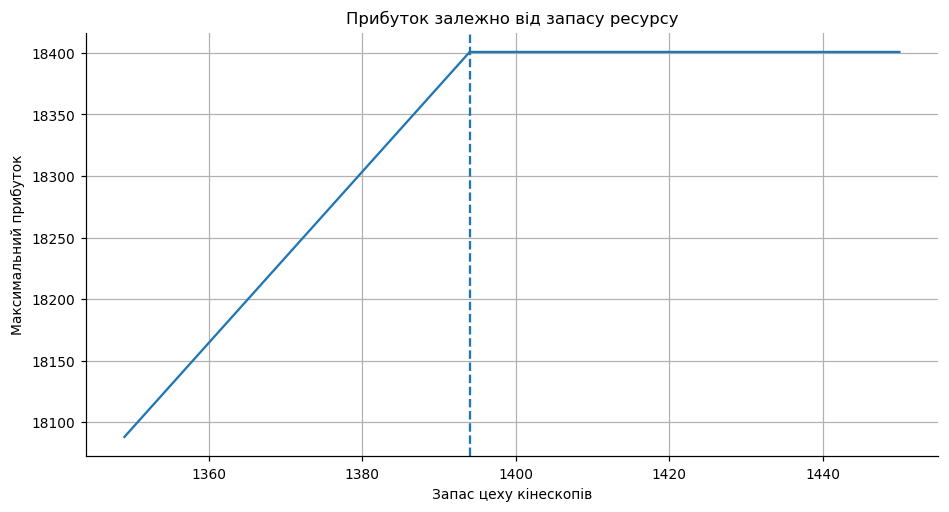

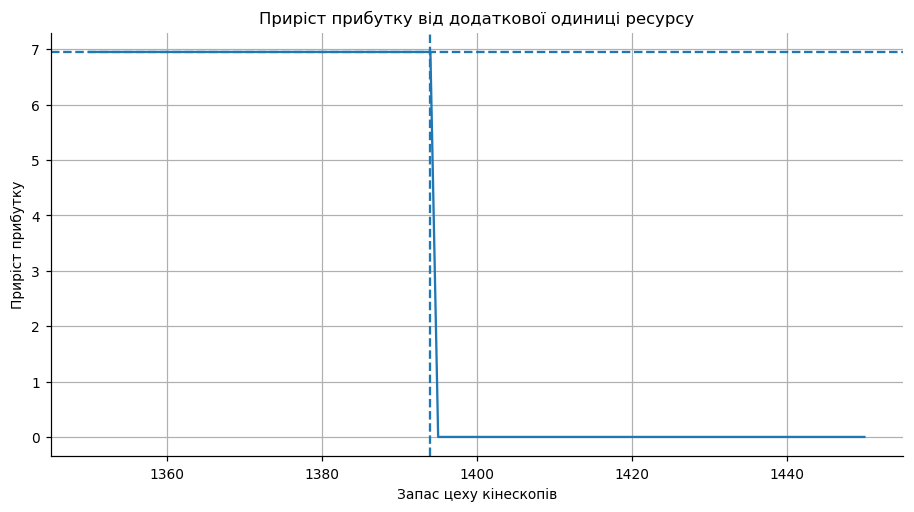

In [49]:
# ВАШ КОД
import numpy as np
import matplotlib.pyplot as plt
from scipy.optimize import linprog

# Цільова функція
c = [-32, -66, -25, -24]

# Витрати ресурсів
A = [
    [3, 0, 6, 6],
    [3, 2, 2, 4],
    [5, 5, 0, 6],   # Цех кінескопів
    [2, 1, 5, 3],
    [5, 5, 4, 2]
]

# Початкові запаси
base_b = [874, 1034, 1349, 845, 1394]

# Перевіряємо запас цеху кінескопів від 1349 до 1450
stocks = np.arange(1349, 1451, 1)

profits = []

for stock in stocks:
    b = base_b.copy()
    b[2] = stock

    result = linprog(
        c,
        A_ub=A,
        b_ub=b,
        bounds=[(0, None)] * 4,
        method='highs'
    )

    profits.append(-result.fun)

profits = np.array(profits)

# Приріст прибутку при збільшенні ресурсу на 1
increments = np.diff(profits)

# Тіньова ціна зі звіту Excel
shadow_price = 6.95

# Знаходимо першу точку, де приріст перестає дорівнювати тіньовій ціні
boundary = None

for i, increase in enumerate(increments):
    if not np.isclose(increase, shadow_price, atol=1e-6):
        boundary = stocks[i]
        break

print("Межа діапазону:", boundary)
print("Тіньова ціна:", shadow_price)

# Графік прибутку
plt.figure(figsize=(10, 5))
plt.plot(stocks, profits)
plt.axvline(boundary, linestyle='--')
plt.xlabel("Запас цеху кінескопів")
plt.ylabel("Максимальний прибуток")
plt.title("Прибуток залежно від запасу ресурсу")
plt.grid()
plt.show()

# Графік приросту прибутку
plt.figure(figsize=(10, 5))
plt.plot(stocks[1:], increments)
plt.axhline(shadow_price, linestyle='--')
plt.axvline(boundary, linestyle='--')
plt.xlabel("Запас цеху кінескопів")
plt.ylabel("Приріст прибутку")
plt.title("Приріст прибутку від додаткової одиниці ресурсу")
plt.grid()
plt.show()

**Відповідь 5.2:** *(на скільки одиниць можна збільшити запас, доки тіньова ціна не зміниться;
чи збігається знайдена межа з «допустимим збільшенням» зі звіту Excel)*

Запас ресурсу можна збільшити на 45 одиниць - з 1349 до 1394 год, доки тіньова ціна залишається 6,95. Знайдена експериментально межа 1394 збігається з допустимим збільшенням зі звіту Excel: 45 одиниць.

---
# Етап 6. Рішення про закупівлю

Постачальник пропонує вам додатковий обсяг ресурсу — див. блок «ПРОПОЗИЦІЯ
ПОСТАЧАЛЬНИКА» у ваших даних.

### Завдання 6.1
Дайте відповідь директорові на три питання, спираючись на числа, а не на здоровий глузд:

1. **Брати чи не брати?** Порівняйте ціну пропозиції з тіньовою ціною.
2. **Скільки саме брати?** Постачальник пропонує більше, ніж вам потрібно.
3. **Скільки на цьому заробимо?** Порахуйте виграш і перевірте його прямим
   розв'язанням задачі з новим запасом.

In [50]:
# ВАШ КОД
from scipy.optimize import linprog

c = [-32, -66, -25, -24]

A = [
    [3, 0, 6, 6],
    [3, 2, 2, 4],
    [5, 5, 0, 6],
    [2, 1, 5, 3],
    [5, 5, 4, 2]
]

base_b = [874, 1034, 1349, 845, 1394]

price = 8.6
max_purchase = 90

best_q = 0
best_total_profit = None

for q in range(max_purchase + 1):
    b = base_b.copy()
    b[2] += q

    result = linprog(
        c,
        A_ub=A,
        b_ub=b,
        bounds=[(0, None)] * 4,
        method='highs'
    )

    production_profit = -result.fun
    total_profit = production_profit - price * q

    if best_total_profit is None or total_profit > best_total_profit:
        best_total_profit = total_profit
        best_q = q

print("Оптимально купити:", best_q)
print("Прибуток після закупівлі:", best_total_profit)

Оптимально купити: 0
Прибуток після закупівлі: 18088.05


**Відповідь 6.1:**

* **Брати чи ні і чому:** не брати, оскільки ціна постачальника 8,60 за одиницю перевищує тіньову ціну ресурсу 6,95. Кожна додаткова одиниця ресурсу дає приріст прибутку лише 6,95.
* **Скільки одиниць має сенс купити і чому не більше:** 0 одиниць, тому що вже перша додаткова одиниця коштує дорожче, ніж дає приросту прибутку.
* **Очікуваний виграш:** 0.
* **Перевірка прямим розв'язанням дала:** оптимально купити 0 одиниць, підсумковий прибуток залишається 18088,05.


---
# Етап 7. Перевірка розв'язку

### Завдання 7.1
Порахуйте дві величини:

* скільки виробів мають **ненульовий** випуск;
* скільки обмежень **зв'язні** (ресурс витрачено повністю).

Порівняйте.

In [51]:
# ВАШ КОД
ненульових = 2
звязних = 2


In [52]:
assert ненульових is not None and звязних is not None, 'спершу порахуйте'
print('ненульових змінних: %s | зв’язних обмежень: %s' % (ненульових, звязних))
assert ненульових == звязних, ('числа не збіглися — це сигнал. Перевірте розв’язок '
                               'і поясніть причину в клітинці нижче')
print('Етап 7 пройдено')

ненульових змінних: 2 | зв’язних обмежень: 2
Етап 7 пройдено


**Відповідь 7.1:** *(чи збіглися числа; що означала б розбіжність на практиці)*
 Числа збіглися: ненульових змінних - 2, зв’язних обмежень - 2. Це означає, що розв’язок відповідає простій перевірці оптимального розв’язку: кількість ненульових змінних дорівнює кількості зв’язних обмежень. Якби числа не збіглися, це могло б вказувати на виродженість або на те, що Solver не дійшов до оптимального розв’язку.

---
# Етап 8. Цілочисельність

Ваш оптимальний план містить дробові числа. Виготовити 63,3 виробу неможливо.

### Завдання 8.1
Порівняйте три варіанти:

1. розв'язок без умови цілочисельності (уже маєте);
2. **округлений** план — округліть кожне значення до цілого й перевірте, чи він
   узагалі допустимий і скільки прибутку дає;
3. справжній **цілочисельний** оптимум — розв'яжіть задачу з умовою, що всі змінні цілі
   (`cat='Integer'` у PuLP або `integrality=1` у `linprog`).

In [53]:
# ВАШ КОД
import numpy as np
from scipy.optimize import linprog, milp, LinearConstraint, Bounds

# Прибуток
profit = np.array([32, 66, 25, 24])

# Витрати ресурсів
A = np.array([
    [3, 0, 6, 6],
    [3, 2, 2, 4],
    [5, 5, 0, 6],
    [2, 1, 5, 3],
    [5, 5, 4, 2]
])

# Запаси
b = np.array([874, 1034, 1349, 845, 1394])

# 1. Розв'язок без умови цілочисельності
lp = linprog(
    -profit,
    A_ub=A,
    b_ub=b,
    bounds=[(0, None)] * 4,
    method='highs'
)

lp_plan = lp.x
lp_profit = -lp.fun

# 2. Просте округлення
rounded_plan = np.rint(lp_plan).astype(int)
rounded_usage = A @ rounded_plan
rounded_feasible = np.all(rounded_usage <= b)
rounded_profit = profit @ rounded_plan

# 3. Справжній цілочисельний оптимум
integer_result = milp(
    -profit,
    integrality=np.ones(4),
    bounds=Bounds(np.zeros(4), np.full(4, np.inf)),
    constraints=LinearConstraint(A, -np.inf, b)
)

integer_plan = np.rint(integer_result.x).astype(int)
integer_profit = -integer_result.fun

print("Без цілочисельності:", lp_plan, "Прибуток:", lp_profit)
print("Округлений план:", rounded_plan, "Прибуток:", rounded_profit,
      "Допустимий:", rounded_feasible)
print("Використання ресурсів округленим планом:", rounded_usage)
print("Цілочисельний оптимум:", integer_plan, "Прибуток:", integer_profit)

Без цілочисельності: [  0.   269.8   11.25   0.  ] Прибуток: 18088.05
Округлений план: [  0 270  11   0] Прибуток: 18095 Допустимий: False
Використання ресурсів округленим планом: [  66  562 1350  325 1394]
Цілочисельний оптимум: [  0 269  12   0] Прибуток: 18054.0


**Відповідь 8.1:**
| Варіант | План | Прибуток | Допустимий? |
|---|---|---:|---|
| без умови цілочисельності | [0; 269,8; 11,25; 0] | 18088,05 | Так математично, але план дробовий |
| округлений | [0; 270; 11; 0] | 18095 | Ні |
| цілочисельний оптимум | [0; 269; 12; 0] | 18054 | Так |

**Висновок:** просто округлювати оптимальний дробовий план не можна. У нашому випадку округлений план порушує обмеження цеху кінескопів: потрібно 1350 год при доступних 1349 год. Правильний цілочисельний оптимум потрібно знаходити окремим розв'язанням задачі з умовою цілочисельності. Він дорівнює [0; 269; 12; 0] з прибутком 18054.



---
# ЧАСТИНА 2. Транспортна задача

Друга частина виконується самостійно. Тут ви застосуєте ту саму методику до задачі
іншого класу — і побачите, що вона поводиться інакше.

# Етап 9. Ваші дані

### Завдання 9.1
Сформуйте власні дані:

* **три міста-постачальники** — за першими трьома літерами вашого **прізвища**;
* **чотири міста-споживачі** — за першими чотирма літерами вашого **імені**;
* **матриця відстаней 3 × 4** — реальні відстані автошляхами за Google Maps, у кілометрах;
* **запаси і попит** — невеликі цілі числа, підберіть так, щоб **сумарний запас
  дорівнював сумарному попиту**.

> Якщо на якусь літеру міста немає — беріть наступну літеру прізвища чи імені.
> Якщо сумарний запас не дорівнює попиту, задача з обмеженнями-рівностями
> **не матиме розв'язку взагалі**. Це не помилка Python — це властивість моделі.

In [54]:
# ВАШ КОД — впишіть свої дані
постачальники = ['Гайсин', 'Ужгород', 'Мукачево']

споживачі = ['Ананьїв', 'Ніжин', 'Андрушівка', 'Суми']

D = np.array([
    [201, 500, 81, 606],
    [900, 980, 750, 1147],
    [850, 939, 700, 1108]
])

запас = [40, 35, 45]

попит = [30, 25, 35, 30]


assert len(постачальники) == 3 and len(споживачі) == 4, 'потрібно 3 постачальники і 4 споживачі'
assert D.shape == (3, 4), 'матриця відстаней має бути 3 x 4'
assert sum(запас) == sum(попит), 'сумарний запас має дорівнювати сумарному попиту'
pd.DataFrame(D, index=постачальники, columns=споживачі)

,Ананьїв,Ніжин,Андрушівка,Суми
Гайсин,201,500,81,606
Ужгород,900,980,750,1147
Мукачево,850,939,700,1108


---
# Етап 10. Розв'язання транспортної задачі

### Завдання 10.1
Розв'яжіть задачу **двічі різними засобами**: наприклад `pulp` і
`scipy.optimize.linprog(method='highs')`. Обмеження — рівності.

Для кожного розв'язку виведіть: оптимальний план перевезень, сумарну вартість
і **тіньові ціни всіх обмежень**.

In [55]:
# ВАШ КОД — розв'язок 1
import numpy as np
import pandas as pd
from scipy.optimize import linprog

m = len(постачальники)
n = len(споживачі)

# Цільова функція: мінімізуємо сумарну відстань/вартість
c = D.flatten()

# Обмеження-рівності
A_eq = []
b_eq = []

# Для кожного постачальника:
# сума відправленого = його запас
for i in range(m):
    row = np.zeros(m * n)
    for j in range(n):
        row[i * n + j] = 1
    A_eq.append(row)
    b_eq.append(запас[i])

# Для кожного споживача:
# сума отриманого = його попит
for j in range(n):
    row = np.zeros(m * n)
    for i in range(m):
        row[i * n + j] = 1
    A_eq.append(row)
    b_eq.append(попит[j])

A_eq = np.array(A_eq)
b_eq = np.array(b_eq)

result = linprog(
    c,
    A_eq=A_eq,
    b_eq=b_eq,
    bounds=(0, None),
    method='highs'
)

# Оптимальний план
plan1 = result.x.reshape(m, n)

print("РОЗВ'ЯЗОК 1 — scipy")
print("\nОптимальний план:")
display(pd.DataFrame(
    plan1,
    index=постачальники,
    columns=споживачі
))

print("Сумарна вартість:", result.fun)

# Тіньові ціни
shadow1 = result.eqlin.marginals

print("\nТіньові ціни обмежень:")

for i in range(m):
    print(
        f"Постачальник {постачальники[i]}:",
        shadow1[i]
    )

for j in range(n):
    print(
        f"Споживач {споживачі[j]}:",
        shadow1[m + j]
    )

РОЗВ'ЯЗОК 1 — scipy

Оптимальний план:


,Ананьїв,Ніжин,Андрушівка,Суми
Гайсин,30.0,0.0,10.0,0.0
Ужгород,0.0,5.0,0.0,30.0
Мукачево,0.0,20.0,25.0,0.0


Сумарна вартість: 82430.0

Тіньові ціни обмежень:
Постачальник Гайсин: -0.0
Постачальник Ужгород: 660.0
Постачальник Мукачево: 619.0
Споживач Ананьїв: 201.0
Споживач Ніжин: 320.0
Споживач Андрушівка: 81.0
Споживач Суми: 487.0


In [56]:
# ВАШ КОД — розв'язок 2
import pulp
import pandas as pd

m = len(постачальники)
n = len(споживачі)

model = pulp.LpProblem(
    "Transportation_problem",
    pulp.LpMinimize
)

# Змінні x[i,j]
x = {}

for i in range(m):
    for j in range(n):
        x[i, j] = pulp.LpVariable(
            f"x_{i}_{j}",
            lowBound=0
        )

# Цільова функція
model += pulp.lpSum(
    D[i][j] * x[i, j]
    for i in range(m)
    for j in range(n)
)

# Обмеження постачальників
for i in range(m):
    model += (
        pulp.lpSum(x[i, j] for j in range(n))
        == запас[i],
        f"supply_{i}"
    )

# Обмеження споживачів
for j in range(n):
    model += (
        pulp.lpSum(x[i, j] for i in range(m))
        == попит[j],
        f"demand_{j}"
    )

model.solve(pulp.PULP_CBC_CMD(msg=False))

# План
plan2 = [
    [x[i, j].value() for j in range(n)]
    for i in range(m)
]

print("РОЗВ'ЯЗОК 2 — PuLP")

print("\nОптимальний план:")
display(pd.DataFrame(
    plan2,
    index=постачальники,
    columns=споживачі
))

print(
    "Сумарна вартість:",
    pulp.value(model.objective)
)

print("\nТіньові ціни обмежень:")

for i in range(m):
    constraint = model.constraints[f"supply_{i}"]
    print(
        f"Постачальник {постачальники[i]}:",
        constraint.pi
    )

for j in range(n):
    constraint = model.constraints[f"demand_{j}"]
    print(
        f"Споживач {споживачі[j]}:",
        constraint.pi
    )

РОЗВ'ЯЗОК 2 — PuLP

Оптимальний план:


,Ананьїв,Ніжин,Андрушівка,Суми
Гайсин,30.0,0.0,10.0,0.0
Ужгород,0.0,5.0,0.0,30.0
Мукачево,0.0,20.0,25.0,0.0


Сумарна вартість: 82430.0

Тіньові ціни обмежень:
Постачальник Гайсин: 201.0
Постачальник Ужгород: 861.0
Постачальник Мукачево: 820.0
Споживач Ананьїв: 0.0
Споживач Ніжин: 119.0
Споживач Андрушівка: -120.0
Споживач Суми: 286.0


### Завдання 10.2 — головне питання цієї частини
Порівняйте два набори тіньових цін.

**Сумарна вартість у двох розв'язувачів однакова. А тіньові ціни?**

Якщо вони різні — це не помилка. Знайдіть закономірність: подивіться на різницю
між відповідними значеннями окремо для постачальників і окремо для споживачів.

In [57]:
# ВАШ КОД — порівняння
# Тіньові ціни з scipy
shadow_scipy = result.eqlin.marginals

# Тіньові ціни з PuLP
shadow_pulp = []

for i in range(m):
    shadow_pulp.append(model.constraints[f"supply_{i}"].pi)

for j in range(n):
    shadow_pulp.append(model.constraints[f"demand_{j}"].pi)

shadow_pulp = np.array(shadow_pulp)

print("Вартість scipy:", result.fun)
print("Вартість PuLP:", pulp.value(model.objective))

print("\nПорівняння тіньових цін:")

for i in range(m):
    print(
        f"Постачальник {постачальники[i]}:",
        "scipy =", shadow_scipy[i],
        "| PuLP =", shadow_pulp[i],
        "| різниця =", shadow_scipy[i] - shadow_pulp[i]
    )

for j in range(n):
    k = m + j
    print(
        f"Споживач {споживачі[j]}:",
        "scipy =", shadow_scipy[k],
        "| PuLP =", shadow_pulp[k],
        "| різниця =", shadow_scipy[k] - shadow_pulp[k]
    )

Вартість scipy: 82430.0
Вартість PuLP: 82430.0

Порівняння тіньових цін:
Постачальник Гайсин: scipy = -0.0 | PuLP = 201.0 | різниця = -201.0
Постачальник Ужгород: scipy = 660.0 | PuLP = 861.0 | різниця = -201.0
Постачальник Мукачево: scipy = 619.0 | PuLP = 820.0 | різниця = -201.0
Споживач Ананьїв: scipy = 201.0 | PuLP = 0.0 | різниця = 201.0
Споживач Ніжин: scipy = 320.0 | PuLP = 119.0 | різниця = 201.0
Споживач Андрушівка: scipy = 81.0 | PuLP = -120.0 | різниця = 201.0
Споживач Суми: scipy = 487.0 | PuLP = 286.0 | різниця = 201.0


**Відповідь 10.2:**

* **Вартість у двох розв'язувачів:** однакова.
* **Тіньові ціни збіглися чи ні:** можуть не збігатися, хоча обидва набори є правильними.
* **Яку закономірність ви побачили в різниці:** для всіх обмежень постачальників різниця між тіньовими цінами є однаковою константою, а для обмежень споживачів - такою самою за модулем, але з протилежним знаком.
* **Що це означає для того, хто збирається ухвалювати рішення за цим звітом:** не можна порівнювати окремі абсолютні значення тіньових цін з різних розв'язувачів без урахування способу їх нормалізації. Важливо, що обидва набори описують той самий оптимальний план і ту саму сумарну вартість.

---
# Етап 11. Перевірка розв'язку — і чому вона тут не працює

### Завдання 11.1
Порахуйте для транспортної задачі те саме, що на етапі 7:

* кількість **ненульових перевезень**;
* кількість **зв'язних обмежень**.

Порівняйте з числом `3 + 4 = 7` — кількістю обмежень у задачі.

In [58]:
# ВАШ КОД
ненульових_перевезень = np.sum(plan1 > 1e-9)
звязних_транспортних = len(постачальники) + len(споживачі)

print("Ненульових перевезень:", ненульових_перевезень)
print("Зв'язних обмежень:", звязних_транспортних)
print("Різниця:", звязних_транспортних - ненульових_перевезень)

Ненульових перевезень: 6
Зв'язних обмежень: 7
Різниця: 1


**Відповідь 11.1:**

* **Ненульових перевезень:** 6.
* **Зв'язних обмежень:** 7.
* **Чому в транспортній задачі зв'язними виявляються всі обмеження:** усі обмеження запасу і попиту задані як рівності, тому в оптимальному плані вони виконуються точно.
* **На скільки ненульових перевезень менше і чому саме на стільки:** на 1. У збалансованій транспортній задачі одне обмеження є залежним від інших, оскільки сумарний запас дорівнює сумарному попиту. Тому незалежних обмежень фактично 3 + 4 - 1 = 6.

### Завдання 11.2 — візуалізація
Побудуйте дві теплові карти поруч: матрицю відстаней і матрицю оптимальних перевезень.
Підпишіть осі та значення в комірках.

*За бажанням (не оцінюється): граф маршрутів через `networkx`, де товщина ребра
пропорційна обсягу перевезення.*

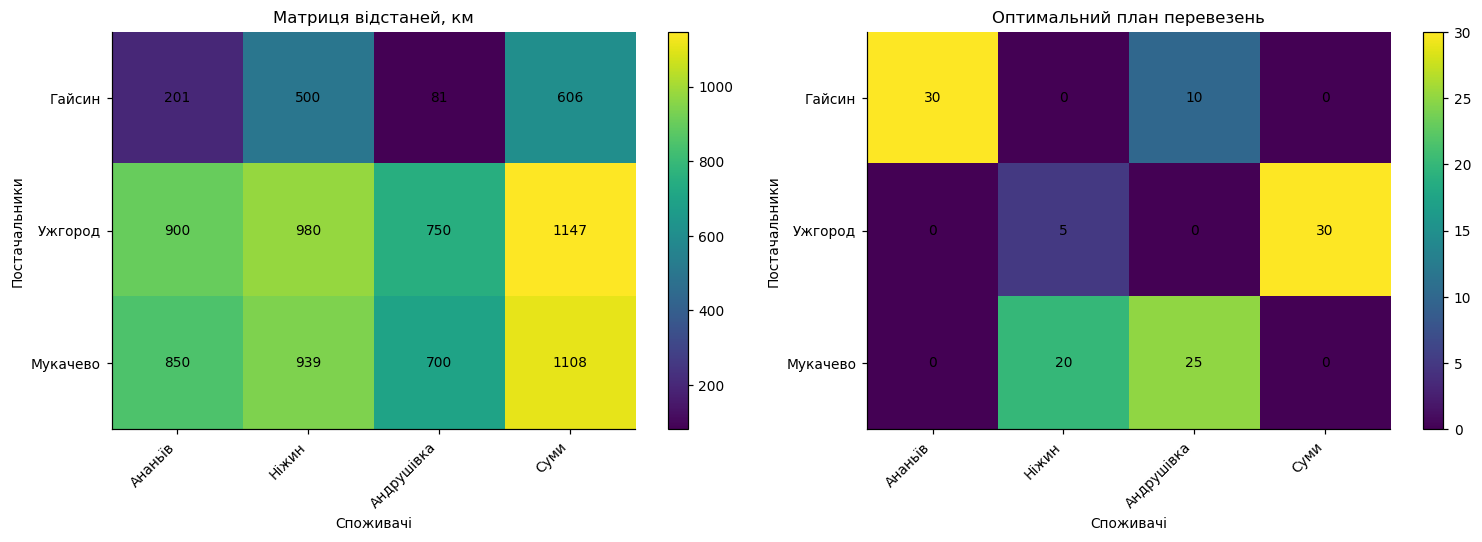

In [59]:
# ВАШ КОД
import numpy as np
import matplotlib.pyplot as plt

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# 1. Теплова карта відстаней
im1 = axes[0].imshow(D, aspect='auto')

axes[0].set_title('Матриця відстаней, км')
axes[0].set_xlabel('Споживачі')
axes[0].set_ylabel('Постачальники')

axes[0].set_xticks(range(len(споживачі)))
axes[0].set_xticklabels(споживачі, rotation=45, ha='right')

axes[0].set_yticks(range(len(постачальники)))
axes[0].set_yticklabels(постачальники)

for i in range(D.shape[0]):
    for j in range(D.shape[1]):
        axes[0].text(
            j, i, f'{D[i, j]:.0f}',
            ha='center', va='center'
        )

fig.colorbar(im1, ax=axes[0])


# 2. Теплова карта оптимальних перевезень
im2 = axes[1].imshow(plan1, aspect='auto')

axes[1].set_title('Оптимальний план перевезень')
axes[1].set_xlabel('Споживачі')
axes[1].set_ylabel('Постачальники')

axes[1].set_xticks(range(len(споживачі)))
axes[1].set_xticklabels(споживачі, rotation=45, ha='right')

axes[1].set_yticks(range(len(постачальники)))
axes[1].set_yticklabels(постачальники)

for i in range(plan1.shape[0]):
    for j in range(plan1.shape[1]):
        axes[1].text(
            j, i, f'{plan1[i, j]:.0f}',
            ha='center', va='center'
        )

fig.colorbar(im2, ax=axes[1])

plt.tight_layout()
plt.show()

**Висновок:** оптимальний план використовує 6 із 12 можливих маршрутів. З Гайсина перевозиться 30 одиниць до Ананьєва та 10 до Андрушівки, з Ужгорода - 5 до Ніжина та 30 до Сум, а з Мукачева — 20 до Ніжина та 25 до Андрушівки. План враховує не лише найкоротші окремі маршрути, а весь баланс запасів і попиту, тому мінімізується сумарна вартість перевезень для всієї системи.

---
# Етап 12. Декларація про використання інструментів штучного інтелекту

Користуватися мовними моделями **дозволено**. Обов'язковою є прозорість.
Порушенням є не використання інструмента, а нездатність пояснити власний код
і власні числа на захисті.

Для кожного етапу оберіть одне: `'ні'`, `'синтаксис'`, `'код, перевірено'`,
`'текст, перероблено'`, `'текст, як є'`.

In [60]:
ІНСТРУМЕНТИ_ШІ = 'ChatGPT'     # напр. 'ChatGPT' або 'не використовував'

ДЕКЛАРАЦІЯ = {
    'етап 1, формалізація моделі':             'текст, перероблено',
    'етап 2, побудова моделі в Excel':         'ні',
    'етап 3, код на Python':                    'код, перевірено',
    'етапи 4–5, читання та перевірка звіту':   'ні',
    'етап 6, рішення про закупівлю':            'текст, перероблено',
    'етапи 7–8, перевірка та цілочисельність': 'код, перевірено',
    'етапи 9–11, транспортна задача':           'код, перевірено',
}


# Що саме ви перевірили за згенерованим кодом чи текстом — конкретно.
ЩО_ПЕРЕВІРЕНО = '''
Перевірила правильність формалізації моделі, обмежень і цільової функції.
Звіряла результати Excel і Python: оптимальний план та значення прибутку.
Перевірила тіньові ціни експериментом зі зміною запасу ресурсу та межу
діапазону стійкості. Перевірила допустимість округленого плану і окремо
знайшла цілочисельний оптимум. Для транспортної задачі перевірила баланс
запасу і попиту, результати двох розв'язувачів, тіньові ціни та побудовані
теплові карти. Код і результати переглянула та адаптувала під свої дані.
'''

# True означає: я можу пояснити кожен рядок свого коду, відтворити будь-яке число
# цієї роботи та внести зміни в модель на вимогу під час захисту.
ПІДТВЕРДЖУЮ = True

In [61]:
# --- перевірка повноти декларації: клітинку не редагувати --------------------
ДОЗВОЛЕНІ = {'ні', 'синтаксис', 'код, перевірено', 'текст, перероблено', 'текст, як є'}
assert ІНСТРУМЕНТИ_ШІ.strip(), 'Вкажіть інструменти або напишіть «не використовував»'
порожні = [k for k, v in ДЕКЛАРАЦІЯ.items() if not str(v).strip()]
assert not порожні, 'Не заповнено: %s' % '; '.join(порожні)
чужі = {v for v in ДЕКЛАРАЦІЯ.values() if v not in ДОЗВОЛЕНІ}
assert not чужі, 'Недопустимі значення: %s' % ', '.join(sorted(чужі))
assert len(ЩО_ПЕРЕВІРЕНО.strip()) >= 120, ('Опишіть конкретніше (зараз %d символів, '
                                           'потрібно щонайменше 120)' % len(ЩО_ПЕРЕВІРЕНО.strip()))
assert ПІДТВЕРДЖУЮ is True, 'Підтвердьте, що можете пояснити власний код на захисті'
print('ДЕКЛАРАЦІЯ ПРО ВИКОРИСТАННЯ ІНСТРУМЕНТІВ ШІ')
print('=' * 78)
print('%-42s %s' % ('автор:', ПІБ))
print('%-42s %s' % ('інструменти:', ІНСТРУМЕНТИ_ШІ))
print('-' * 78)
for k, v in ДЕКЛАРАЦІЯ.items():
    print('%-42s %s' % (k + ':', v))
print('-' * 78)
print(ЩО_ПЕРЕВІРЕНО)

ДЕКЛАРАЦІЯ ПРО ВИКОРИСТАННЯ ІНСТРУМЕНТІВ ШІ
автор:                                     Гуменюк Анастасія
інструменти:                               ChatGPT
------------------------------------------------------------------------------
етап 1, формалізація моделі:               текст, перероблено
етап 2, побудова моделі в Excel:           ні
етап 3, код на Python:                     код, перевірено
етапи 4–5, читання та перевірка звіту:     ні
етап 6, рішення про закупівлю:             текст, перероблено
етапи 7–8, перевірка та цілочисельність:   код, перевірено
етапи 9–11, транспортна задача:            код, перевірено
------------------------------------------------------------------------------

Перевірила правильність формалізації моделі, обмежень і цільової функції.
Звіряла результати Excel і Python: оптимальний план та значення прибутку.
Перевірила тіньові ціни експериментом зі зміною запасу ресурсу та межу
діапазону стійкості. Перевірила допустимість округленого плану і окремо
з

---
# Крок 13. Фінальна самоперевірка

In [62]:
перевірки = {
    'ПІБ і варіант заповнено':            bool(ПІБ) and 1 <= ВАРІАНТ <= 30,
    'Excel і Python дали однаковий план': abs(прибуток - EXCEL_ПРИБУТОК) < 0.5,
    'перевірку «ненульові = зв’язні» зроблено': ненульових == звязних,
    'дані транспортної задачі введено':   len(постачальники) == 3 and len(споживачі) == 4,
    'баланс запасів і попиту':            sum(запас) == sum(попит),
    'декларацію заповнено':               bool(ІНСТРУМЕНТИ_ШІ.strip()) and ПІДТВЕРДЖУЮ is True,
}
for k, v in перевірки.items():
    print(('OK   ' if v else 'НЕ ОК') + '  ' + k)
if all(перевірки.values()):
    print('\nТехнічна частина виконана.')
    print('Переконайтеся, що заповнені ВСІ клітинки з відповідями,')
    print('і виконайте Kernel → Restart & Run All перед здачею.')

OK     ПІБ і варіант заповнено
OK     Excel і Python дали однаковий план
OK     перевірку «ненульові = зв’язні» зроблено
OK     дані транспортної задачі введено
OK     баланс запасів і попиту
OK     декларацію заповнено

Технічна частина виконана.
Переконайтеся, що заповнені ВСІ клітинки з відповідями,
і виконайте Kernel → Restart & Run All перед здачею.
